-------- INITIAL PARAMETERS --------
d_wire / d :       0.4
Beam diameter at CRL3 :       650 µm
Beam diameter at CRL4a :       200 µm
Distance between CRL4a and TCC :       1.40 m
Distance between CRL4a and O1 :       6.00 m
Distance between TCC and Detector :       10.00 m
Position of O2:                   7.700 m
Diameter of O2:                   50.00 µm
-------- CALCULATED PARAMETERS --------
Focal length of CRL3:       10.978 m
Focal length of CRL4a:       2.391 m
O1 image position:   2.575 m
Magnification:               0.663
Diameter of O1:              222.11 µm
Diameter of image of O1:     147.15 µm
Position of CRL4b:   3.075 m
Focal length of CRL4b:      2.129 m
Magnification (CRL4b):      2.252
Distance between TCC and image of O2:          7.224 m
Diameter of image of O2:          47.41 µm
d/2f:          71.43 µrad
--------------------------


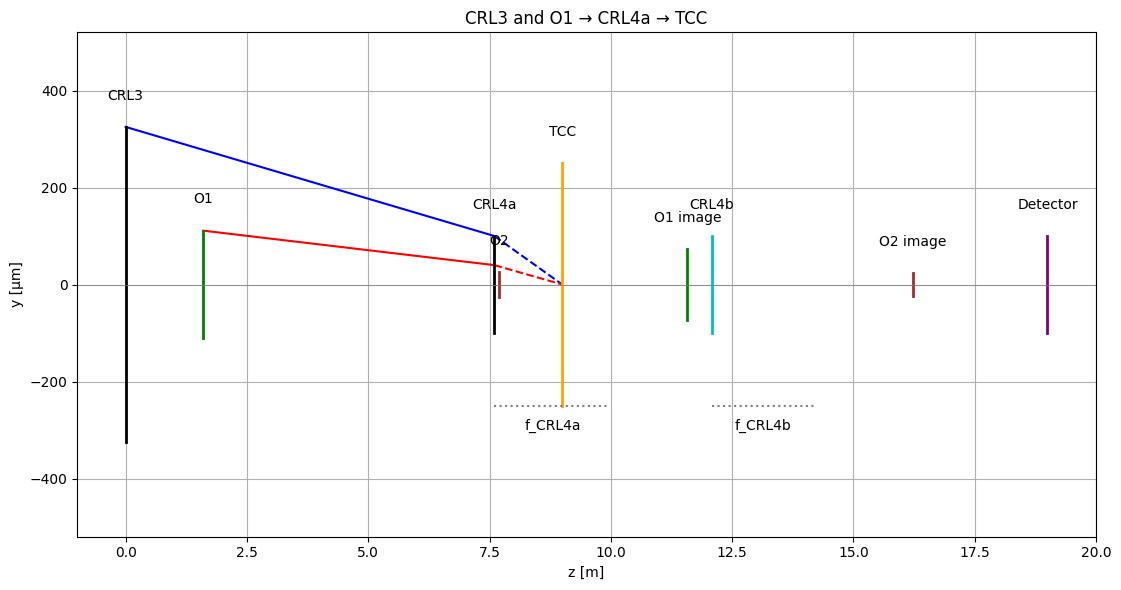

In [7]:
########################## RAY OPTICS CALCULATIONS OF DF SETUP PARAMETERS ###################
# Distances are absolute (no "-" sign here).

import os
import sys
import numpy as np
import matplotlib.pyplot as plt


D_crl3 = 650e-6 #beam diameter at CRL3
D_crl4a = 200e-6 #beam diameter at CRL4a

X1 = 9   # distance between TCC and CRL3
X2 = 1.4 # distance between CRL4a and TCC
X3 = 6   # distance between CRL4a and O1
X9 = 10.0  # Distance between TCC and detector

d_wire_over_d = 0.4 # Ratio of the beam to wire diameter

d_wire = D_crl4a * d_wire_over_d #diameter of the wire

f_crl4a = np.abs (D_crl4a / ( (D_crl3-D_crl4a)/(X1-X2) - D_crl4a/X2 )) #focal lenght of the CRL4a lens

X4 = 1 / (1/f_crl4a - 1/X3) #distance between CRL4a and O1 image

Magnification = X4 / X3 #magnification of CRL4a lens

theta1_in = d_wire / 2 * (1 / X2 - 1 / f_crl4a)  # Angle of the rays coming from O1, just before CRL4A, and ending up at TCC.

Diam_O1 = 2 * (d_wire / 2 + theta1_in * X3 )  #diameter of O1

Diam_img_O1 = Diam_O1 * Magnification #diameter of the image of O1

f_crl3 = (X1 - X2) / (1 - D_crl4a / D_crl3) #focal length of CRL3

# New lens: CRL4b
X5 = 0.5   # Distance between O1 image and CRL4b
z_crl4b = X1 - X2 + X4 + X5  # Absolute position of CRL4b
z_detector = X1 + X9    # Absolute position of detector
d_obj = z_crl4b - X1    # object = TCC
d_img = z_detector - z_crl4b
f_crl4b = 1 / (1 / d_obj + 1 / d_img)
magnification_crl4b = d_img / d_obj

# z positions
z_crl3 = 0
z_crl4a = X1 - X2
z_tcc import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

# Create example image
N = 256
LightPipe_img = np.random.rand(N, N)  # or use your actual intensity map

# Create identity kernel
kernel2D = np.zeros((N, N))
kernel2D[N//2, N//2] = 1.0

# Convolution
convolved = fftconvolve(LightPipe_img, kernel2D, mode='same')

# Check if they match
print("Max absolute difference:", np.max(np.abs(LightPipe_img - convolved)))

# Plot to visually confirm
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(LightPipe_img, cmap='inferno')
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(convolved, cmap='inferno')
plt.title("After convolution")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(convolved - LightPipe_img), cmap='viridis')
plt.title("Absolute difference")

plt.tight_layout()
plt.show()
= X1
z_O1 = z_crl4a - X3
z_O1_img = z_crl4a + X4
f_line_y = -250  # in microns, for focal length line display

# Beam edge positions (in meters)
y_crl3 = D_crl3 / 2
y_crl4a = D_crl4a / 2
y_o1 = Diam_O1 / 2
y_wire = d_wire / 2

# ---------------- O2 OBJECT AND ITS IMAGE (THROUGH CRL4b) ------------------
Diam_O2 = 50e-6  # 50 µm
z_O2 = z_crl4a + 0.1  # 10 cm after CRL4a

# Object distance from CRL4b
d_O2_obj = z_crl4b - z_O2
# Image distance from CRL4b
d_O2_img = 1 / (1 / f_crl4b - 1 / d_O2_obj)
# Position of the image
z_O2_img = z_crl4b + d_O2_img
# Magnification
Magnif_O2 = d_O2_img / d_O2_obj
# Image size
Diam_img_O2 = Diam_O2 * Magnif_O2

print("-------- INITIAL PARAMETERS --------")
print(f"d_wire / d :       {d_wire_over_d:.1f}")
print(f"Beam diameter at CRL3 :       {D_crl3*1e6:.0f} µm")
print(f"Beam diameter at CRL4a :       {D_crl4a*1e6:.0f} µm")
print(f"Distance between CRL4a and TCC :       {X2:.2f} m")
print(f"Distance between CRL4a and O1 :       {X3:.2f} m")
print(f"Distance between TCC and Detector :       {X9:.2f} m")
print(f"Position of O2:                   {z_O2:.3f} m")
print(f"Diameter of O2:                   {Diam_O2*1e6:.2f} µm")

print("-------- CALCULATED PARAMETERS --------")
print(f"Focal length of CRL3:       {f_crl3:.3f} m")
print(f"Focal length of CRL4a:       {f_crl4a:.3f} m")
print(f"O1 image position:   {X4-X2:.3f} m")
print(f"Magnification:               {Magnification:.3f}")
print(f"Diameter of O1:              {Diam_O1*1e6:.2f} µm")
print(f"Diameter of image of O1:     {Diam_img_O1*1e6:.2f} µm")
print(f"Position of CRL4b:   {X4-X2+X5:.3f} m")
print(f"Focal length of CRL4b:      {f_crl4b:.3f} m")
print(f"Magnification (CRL4b):      {magnification_crl4b:.3f}")
print(f"Distance between TCC and image of O2:          {z_O2_img-z_tcc:.3f} m")
print(f"Diameter of image of O2:          {Diam_img_O2*1e6:.2f} µm")
print(f"d/2f:          {D_crl4a/(2*X2)*1e6:.2f} µrad")
print("--------------------------")



################ RAY TRACING OF THE PARAMETERS ABOVE ############

fig, ax = plt.subplots(figsize=(20, 6))


### ---------- BLUE RAY: from CRL3 to TCC ----------
# Slope from CRL3 to CRL4a
slope_in = (y_crl4a - y_crl3) / (z_crl4a - z_crl3)
# Slope from CRL4a to TCC
slope_out = -y_crl4a / (z_tcc - z_crl4a)

# Coordinates
z_vals1 = [z_crl3, z_crl4a]
y_vals1 = [y_crl3 * 1e6, y_crl4a * 1e6]
z_vals2 = [z_crl4a, z_tcc]
y_vals2 = [y_crl4a * 1e6, 0]

# Plot blue rays
ax.plot(z_vals1, y_vals1, 'b')
ax.plot(z_vals2, y_vals2, 'b--')

### ---------- RED RAY: from O1 to TCC ----------
# Slope from O1 to CRL4a
slope_o1_in = (y_wire - y_o1) / (z_crl4a - z_O1)
# Slope from CRL4a to TCC (same as before: converge to axis)
slope_o1_out = -y_wire / (z_tcc - z_crl4a)

# Coordinates
z_vals3 = [z_O1, z_crl4a]
y_vals3 = [y_o1 * 1e6, y_wire * 1e6]
z_vals4 = [z_crl4a, z_tcc]
y_vals4 = [y_wire * 1e6, 0]

# Plot red rays
ax.plot(z_vals3, y_vals3, 'r')
ax.plot(z_vals4, y_vals4, 'r--')

### ---------- Optical elements ----------
def draw_aperture(z, D, label, color='k'):
    ax.plot([z, z], [-D/2*1e6, D/2*1e6], color=color, lw=2)
    ax.text(z, D/2*1e6 + 50, label, ha='center', va='bottom', fontsize=10)

draw_aperture(z_crl3, D_crl3, 'CRL3')
draw_aperture(z_crl4a, D_crl4a, 'CRL4a')
draw_aperture(z_tcc, 0.5e-3, 'TCC', 'orange')
draw_aperture(z_O1, Diam_O1, 'O1', 'g')
draw_aperture(z_O1_img, Diam_img_O1, 'O1 image', 'g')
draw_aperture(z_crl4b, D_crl4a, 'CRL4b', 'c')
draw_aperture(z_detector, D_crl4a, 'Detector', 'purple')
draw_aperture(z_O2, Diam_O2, 'O2', 'brown')
draw_aperture(z_O2_img, Diam_img_O2, 'O2 image', 'brown')

### ---------- Focal length ----------
ax.hlines(f_line_y, z_crl4a, z_crl4a + f_crl4a, colors='gray', linestyles='dotted')
ax.text(z_crl4a + f_crl4a/2, f_line_y - 50, 'f_CRL4a', ha='center', fontsize=10)

ax.hlines(f_line_y, z_crl4b, z_crl4b + f_crl4b, colors='gray', linestyles='dotted')
ax.text(z_crl4b + f_crl4b/2, f_line_y - 50, 'f_CRL4b', ha='center', fontsize=10)

### ---------- Formatting ----------
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel("z [m]")
ax.set_ylabel("y [µm]")
ax.set_title("CRL3 and O1 → CRL4a → TCC")
ax.set_xlim(z_crl3 - 0.5, z_O1_img + 0.5)
ax.set_ylim(f_line_y - 50, y_crl3 * 1e6 + 100)
ax.grid(True)
plt.tight_layout()
plt.xlim([-1, 20])
plt.ylim([-520,520])
plt.show()


/tmp/ipykernel_1670215/1145469700.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


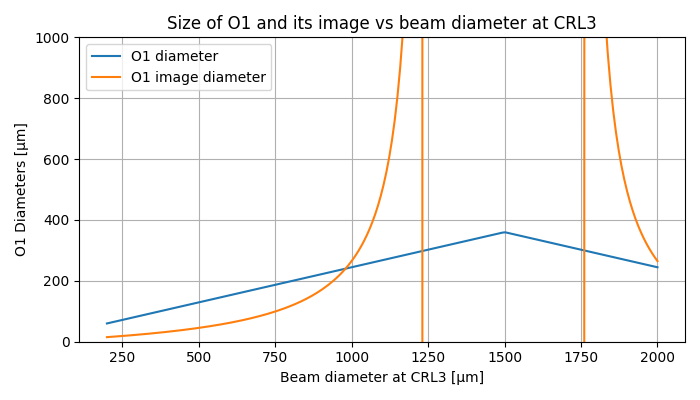

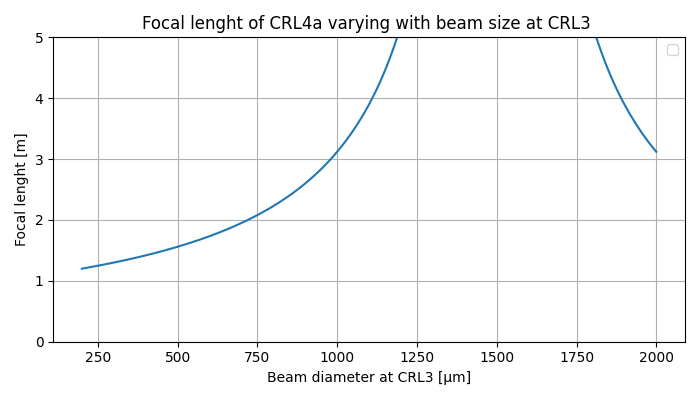

In [13]:
################# PLOT OF THE SIZE OF O1 AND O1 IMAGE AS A FUNCTION OF BEAM DIAMETER AT CRL3 #############
# Fixed parameters
D_crl4a = 200e-6      # 200 µm
X1 = 9                # Distance CRL3 to TCC
X2 = 1.2              # Distance CRL4a to TCC
d_wire_over_d = 0.3   # Beam/wire ratio

# 1. Diameter of O1 and its image vs D_crl3
D_crl3_values = np.linspace(200e-6, 2000e-6, 200)  # 200 µm to 2000 µm
Diam_O1_list = []
Diam_img_O1_list = []
Focal_length_list = []

X3_fixed = 6  # Fixed O1 to CRL4a distance

for D_crl3 in D_crl3_values:
    d_wire = D_crl4a * d_wire_over_d

    f_crl4a = np.abs(D_crl4a / ((D_crl3 - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3_fixed)
    M = X4 / X3_fixed

    theta1_in = d_wire / 2 * (1 / X2 - 1 / f_crl4a)
    Diam_O1 = 2 * (d_wire / 2 + theta1_in * X3_fixed)
    Diam_img_O1 = Diam_O1 * M

    Diam_O1_list.append(Diam_O1 * 1e6)
    Diam_img_O1_list.append(Diam_img_O1 * 1e6)
    Focal_length_list.append(f_crl4a)

############## Plot of the size of O1 and image of O1 as a function of the beam diameter at CRL3 ############
plt.figure(figsize=(7,4))
plt.plot(D_crl3_values * 1e6, Diam_O1_list, label="O1 diameter")
plt.plot(D_crl3_values * 1e6, Diam_img_O1_list, label="O1 image diameter")
plt.xlabel("Beam diameter at CRL3 [µm]")
plt.ylabel("O1 Diameters [µm]")
plt.ylim([0,1000])
plt.title("Size of O1 and its image vs beam diameter at CRL3")
plt.grid(True)
plt.legend()
plt.tight_layout()

############## Plot of the focal lenght of CRL4a as a function of the beam diameter at CRL3 ############
plt.figure(figsize=(7,4))
plt.plot(D_crl3_values * 1e6, Focal_length_list)
plt.xlabel("Beam diameter at CRL3 [µm]")
plt.ylabel("Focal lenght [m]")
plt.ylim([0,5])
plt.title("Focal lenght of CRL4a varying with beam size at CRL3 ")
plt.grid(True)
plt.legend()
plt.tight_layout()

In [ ]:
############### PLOT OF THE IMAGE DISTANCE VS THE OBJECT DISTANCE ##########
X3_values = np.linspace(5, 8, 200)
X4_list = []

D_crl3_fixed = 1e-3  # 1000 µm

for X3 in X3_values:
    f_crl4a = np.abs(D_crl4a / ((D_crl3_fixed - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3)
    X4_list.append(X4)

plt.figure(figsize=(7,4))
plt.plot(X3_values, X4_list)
plt.xlabel("Distance between O1 and CRL4a [m]")
plt.ylabel("Distance between CRL4a and O1 image [m]")
plt.title("O1 Image distance vs. object distance")
plt.grid(True)
plt.tight_layout()

In [ ]:
############# PLOT OF O1 and O1 image SIZE VS DISTANCE BETWEEN O1 AND CRL4A ############
Diam_O1_list_2 = []
Diam_img_O1_list_2 = []

for X3 in X3_values:
    d_wire = D_crl4a * d_wire_over_d
    f_crl4a = np.abs(D_crl4a / ((D_crl3_fixed - D_crl4a) / (X1 - X2) - D_crl4a / X2))
    X4 = 1 / (1/f_crl4a - 1/X3)
    M = X4 / X3

    theta1_in = d_wire / 2 * (1 / X2 - 1 / f_crl4a)
    Diam_O1 = 2 * (d_wire / 2 + theta1_in * X3)
    Diam_img_O1 = Diam_O1 * M

    Diam_O1_list_2.append(Diam_O1 * 1e6)
    Diam_img_O1_list_2.append(Diam_img_O1 * 1e6)

plt.figure(figsize=(7,4))
plt.plot(X3_values, Diam_O1_list_2, label="O1 diameter")
plt.plot(X3_values, Diam_img_O1_list_2, label="O1 image diameter")
plt.xlabel("Distance between O1 and CRL4a [m]")
plt.ylabel("Diameter of O1 and image of O1 [µm]")
plt.title("Size of O1 and its image vs object distance")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

-------- INITIAL PARAMETERS --------
d_wire / d :       0.4
Beam diameter at CRL3 :       201 µm
Beam diameter at CRL4a :       200 µm
Distance between CRL4a and TCC :       1.20 m
Distance between CRL4a and O1 :       2.00 m
Distance between TCC and Detector :       10.00 m
Position of O2:                   7.900 m
Diameter of O2:                   50.00 µm
-------- CALCULATED PARAMETERS --------
Focal length of CRL3:       1567.800 m
Focal length of CRL4a:       1.201 m
Distance between CRL4a and O1 image :   3.006 m
Magnification:               1.503
Diameter of O1:              80.10 µm
Diameter of image of O1:     120.39 µm
Focal length of CRL4b:      1.774 m
Magnification (CRL4b):      3.337
Distance between TCC and image of O2:          6.009 m
Diameter of image of O2:          54.37 µm
--------------------------


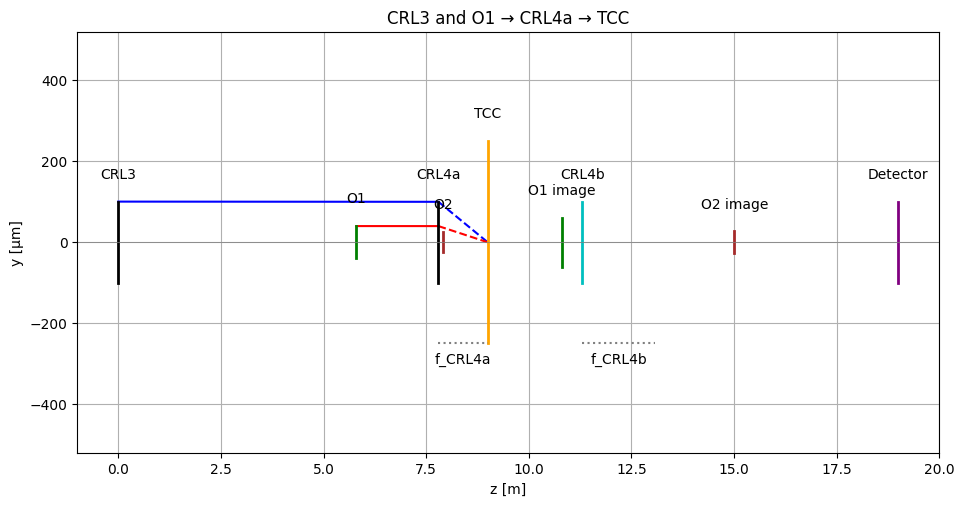

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_wireslit_profiles(r=0.0002, size=60e-6, pxsize=0.1e-6, N=8000):
    # Derived quantities
    N2 = int(N / 2)
    Na = (np.arange(N) - N2) * pxsize
    x = Na.copy()
    halfsize = size / 2
    off = halfsize + r

    # Original (incorrect) version
    wireprof_orig = np.zeros_like(x)
    circ1 = np.sqrt(np.clip(r**2 - (Na - off)**2, 0, None)) * 2
    sel1 = (x >= halfsize) & (x <= off)
    wireprof_orig[sel1] = circ1[sel1]

    circ2 = np.sqrt(np.clip(r**2 - (Na + off)**2, 0, None)) * 2
    sel2_wrong = (x <= halfsize) & (x >= -off)  # incorrect
    wireprof_orig[sel2_wrong] = circ2[sel2_wrong]

    wireprof_orig[np.abs(x) > off] = 2 * r
    wireprof_orig[np.abs(x) < halfsize] = 0

    # Corrected version
    wireprof_corr = np.zeros_like(x)
    circ1 = np.sqrt(np.clip(r**2 - (Na - off)**2, 0, None)) * 2
    wireprof_corr[sel1] = circ1[sel1]

    circ2 = np.sqrt(np.clip(r**2 - (Na + off)**2, 0, None)) * 2
    sel2_correct = (x <= -halfsize) & (x >= -off)
    wireprof_corr[sel2_correct] = circ2[sel2_correct]

    wireprof_corr[np.abs(x) > off] = 2 * r
    wireprof_corr[np.abs(x) < halfsize] = 0

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x * 1e6, wireprof_orig * 1e6, label='Original (incorrect sel2)')
    plt.plot(x * 1e6, wireprof_corr * 1e6, '--', label='Corrected sel2')
    plt.xlabel('x [µm]')
    plt.ylabel('Thickness [µm]')
    plt.title('WireSlit Profile: Original vs Corrected')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the function with the TCS slit parameters
plot_wireslit_profiles()


In [21]:
from darkfield.diffra_v2 import build_symmetric_kernel_from_particles
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

data = np.load("/home/yu79deg/darkfield_p5438/Air_scattering/xray_Primaries2e9_50umKapton_Air_stats.npz")
x_particles = data["x"]
y_particles = data["y"]
e_particles = data["e"]

#propsize = 0.000659 # box size, in [m]
propsize = 250e-6 # box size, in [m]
N = 4000
half_size_um = propsize * 1e6 / 2
Initial_energy_Geant4 = 8.8 #keV

kernel_2D_1ermethod, radial_hist, r_bins, radial_density , radial_density_smooth = build_symmetric_kernel_from_particles( x_particles, y_particles, e_particles,  Initial_energy_Geant4, N=N, propsize=propsize,
    nbins= N, smooth_sigma=8.0, plot_debug=False)
kernel_2D_1ermethod /= np.sum(kernel_2D_1ermethod)  # normalise the kernel such that its sum is 1.

kernel_2D_2ememethod, _, _ = np.histogram2d(x_particles, y_particles, bins = N, range = [[-half_size_um, half_size_um], [-half_size_um, half_size_um]])

kernel_2D_2ememethod /= np.sum(kernel_2D_2ememethod)  # normalise the kernel such that its sum is 1.

    
nb_particles_after_scattering = len(x_particles) # total number of particles ending on the screen after scattering
nb_primaries = 2e9 #number of primary particles (nb of particles intialised in the simulation)

transmission_factor = nb_particles_after_scattering / nb_primaries #percentage of particles making it through

kernel_2D_1ermethod *= transmission_factor  # Take into account that some particles are absorbed by air
kernel_2D_2ememethod *= transmission_factor  # Take into account that some particles are absorbed by air

radial_density_smooth /= np.sum(radial_density_smooth)
radial_density_smooth *= transmission_factor



In [15]:
############ SUMMING EVERYTHING IN AND OUT THE CENTER X=Y=0 ############
Initial_number_particles = 2e9
mask_at_origin = (x_particles == 0) & (y_particles == 0)
n_at_origin = np.sum(mask_at_origin)
n_elsewhere = len(x_particles) - n_at_origin
print(f"Particles at x=0, y=0: {n_at_origin}")
print(f"Particles elsewhere: {n_elsewhere}")
print(f"Percentage of particles in x=y=0 : {n_at_origin/Initial_number_particles*100}%")
print(f"Percentage of particles elsewhere : {n_elsewhere/Initial_number_particles*100}%")

Particles at x=0, y=0: 885143180
Particles elsewhere: 462916
Percentage of particles in x=y=0 : 44.257159%
Percentage of particles elsewhere : 0.0231458%


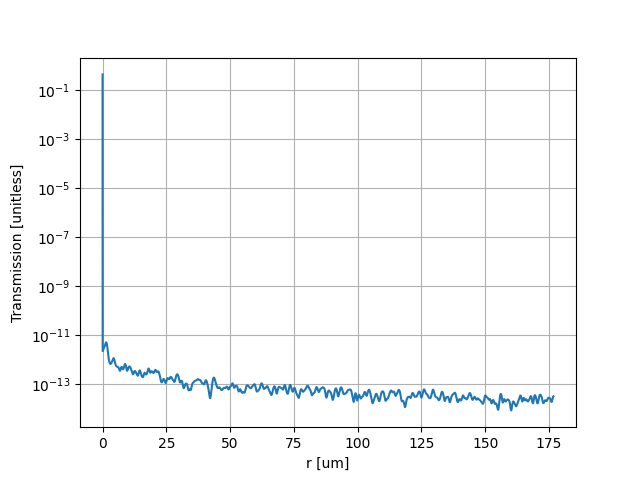

In [42]:
%matplotlib widget

plt.figure()
plt.plot(r_bins[:-1],radial_density_smooth)
plt.xlabel("r [um]")
plt.ylabel("Transmission [unitless]")
plt.yscale('log')
plt.grid(True)

In [70]:
SumCurve = np.sum(radial_density_smooth[1:]) * 2e9

Len_x = len(x_particles)

print(SumCurve,Len_x)

1.1557713073061902 885606096


In [69]:
Initial_number_particles = 2e9

cutoff_um = 1e6

mask = ((0 < np.abs(x_particles)) & (np.abs(x_particles) < cutoff_um) &
        (0 < np.abs(y_particles)) & (np.abs(y_particles) < cutoff_um))

#mask_at_origin = (x_particles == 0) & (y_particles == 0)
n_particles_filtered = np.sum(mask)
#n_elsewhere = len(x_particles) - n_at_origin
print(n_particles_filtered)

462916


In [55]:
print(np.sum(x_particles),len(x_particles))

-781866.9087907798 885606096


In [66]:
total = np.sum(curve[1:])

0.035

In [8]:
from matplotlib.colors import LogNorm

%matplotlib widget

# Remove only particles at (0, 0)
half_size_um = propsize * 1e6 / 2   # assuming propsize is already defined

# Filter particles: keep only those within the box and not at (0, 0)
valid = (
    (np.abs(x_particles) <= half_size_um) &
    (np.abs(y_particles) <= half_size_um) &
    ~((x_particles == 0) & (y_particles == 0))
)

x_valid = x_particles[valid]
y_valid = y_particles[valid]
e_valid = e_particles[valid]

# Downsample for performance
max_points = 1000000
if len(x_valid) > max_points:
    idx = np.random.choice(len(x_valid), max_points, replace=False)
    x_plot = x_valid[idx]
    y_plot = y_valid[idx]
    e_plot = e_valid[idx]
else:
    x_plot = x_valid
    y_plot = y_valid
    e_plot = e_valid

# Plot
plt.figure(figsize=(7, 6))
vmin = 7
vmax = 9
sc = plt.scatter(x_plot, y_plot, c=e_plot, cmap='hsv', s=1, alpha=0.5,vmin=vmin, vmax=vmax)
plt.xlabel("x [µm]")
plt.ylabel("y [µm]")
plt.title("Particle positions colored by energy (excluding (0,0))")
cbar = plt.colorbar(sc)
cbar.set_label("Energy [keV]")
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'propsize' is not defined

In [17]:
np.max(e_valid)

np.float64(8.799999998457592)

In [ ]:
0

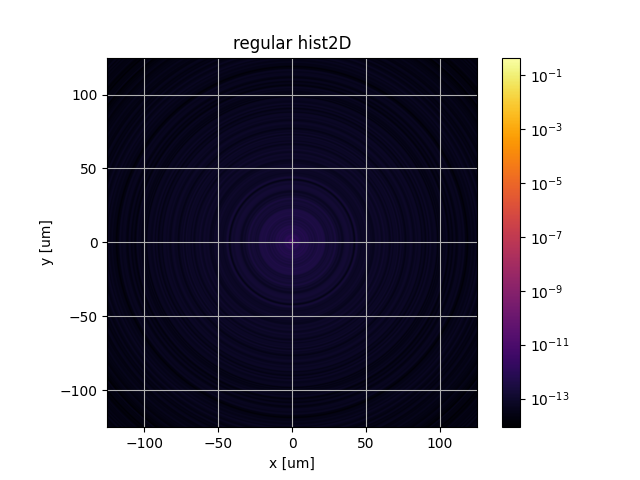

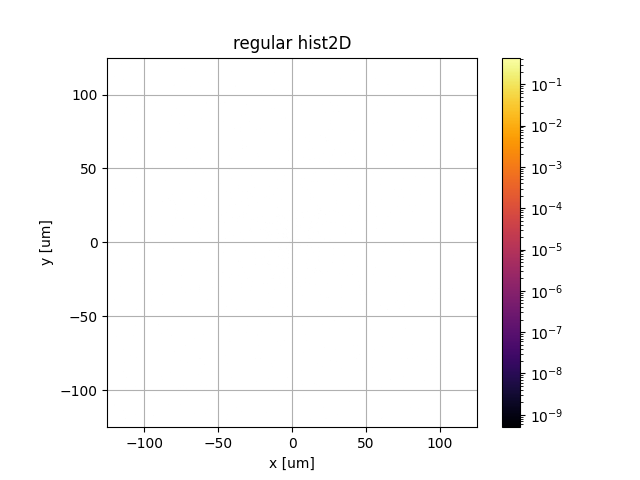

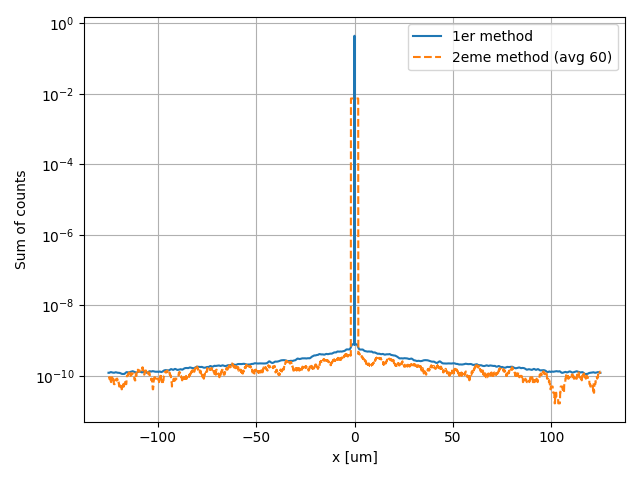

In [9]:
from matplotlib.colors import LogNorm
from scipy.ndimage import uniform_filter1d  # for simple averaging
%matplotlib widget

plt.figure()
plt.imshow(kernel_2D_1ermethod, cmap='inferno', norm=LogNorm(), extent=[-half_size_um, half_size_um, -half_size_um, half_size_um], origin='lower')
plt.title("regular hist2D")
plt.xlabel("x [um]")
plt.ylabel("y [um]")
plt.colorbar()
#plt.clim(1e-9, 1e0)
plt.grid(True)

plt.figure()
plt.imshow(kernel_2D_2ememethod, cmap='inferno', norm=LogNorm(), extent=[-half_size_um, half_size_um, -half_size_um, half_size_um], origin='lower')
plt.title("regular hist2D")
plt.xlabel("x [um]")
plt.ylabel("y [um]")
plt.colorbar()
#plt.clim(1e-9, 1e0)
plt.grid(True)


average_width = 60  # adjust this to control the smoothing width
integ_kernel_2D_1ermethod = np.sum(kernel_2D_1ermethod, axis=0)
integ_kernel_2D_2ememethod = np.sum(kernel_2D_2ememethod, axis=0)
integ_kernel_2D_2ememethod_smooth = uniform_filter1d(integ_kernel_2D_2ememethod, size=average_width)
x_vals = propsize/N * (np.arange(len(integ_kernel_2D_1ermethod)) - len(integ_kernel_2D_1ermethod)//2) * 1e6
plt.figure()
plt.plot(x_vals,integ_kernel_2D_1ermethod, label="1er method", linestyle='-')
plt.plot(x_vals,integ_kernel_2D_2ememethod_smooth, label=f"2eme method (avg {average_width})", linestyle='--')
plt.yscale('log')
plt.xlabel("x [um]")
plt.ylabel("Sum of counts")
plt.legend()
plt.grid(True)
plt.tight_layout()



In [1]:
#################### NEW TEST : AIR SCATTERING ###########

from darkfield.diffra_v2 import build_symmetric_kernel_from_particles
from darkfield.diffra_v2 import apply_air_scattering_and_debug_plot
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import darkfield.mmmUtils_v2 as mu

data = np.load("/home/yu79deg/darkfield_p5438/Air_scattering/xray_Primaries2e9_50umKapton_Air_stats.npz")
x_particles = data["x"]
y_particles = data["y"]
e_particles = data["e"]


########### CHARGER UNE IMAGE DE SIMU ########

project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_tag = 'LP_576'  # Simulation name
plane_to_visualize = 'Det'  # Name of the plane to display

# Construct pickle file path
pickle_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_figs.pickle')
print(f"Loading: {pickle_file}")

# Load image dictionary
figs = mu.loadPickle(pickle_file)

for plane_name, data in figs.items():
    if plane_name != plane_to_visualize:
        continue

    img = data[0]
    N = img.shape[0]
    propsize = data[2] #total size of the box
    pixel_size = propsize / N
    pixel_size_um = pixel_size * 1e6  # Convert to microns

Loading: /home/yu79deg/darkfield_p5438/Aime/pickles/LP_576_figs.pickle


In [ ]:
   
half_size_um = propsize * 1e6 / 2
Initial_energy_Geant4 = 8.8 #keV


kernel_2D, radial_hist, r_bins, radial_density , radial_density_smooth = build_symmetric_kernel_from_particles(x_particles, 
                                                                                                               y_particles, 
                                                                                                               e_particles, 
                                                                                                               Initial_energy_Geant4, 
                                                                                                               N, propsize, 
                                                                                                               nbins = N, 
                                                                                                               smooth_sigma=8.0, 
                                                                                                               plot_debug=False)

compute_transmission = 1
use_symmetric_kernel = 1
test_identity_kernel = 1
crop_to_odd = 1

params={}
params["projectdir"] = "/home/yu79deg/darkfield_p5438/Aime"

I_after_air = apply_air_scattering_and_debug_plot(img,
                                                  params, 
                                                  propsize, 
                                                  N, 
                                                  plot_debug = True, 
                                                  use_symmetric_kernel = use_symmetric_kernel, compute_transmission = compute_transmission,
                                                  test_identity_kernel = test_identity_kernel , crop_to_odd = crop_to_odd)

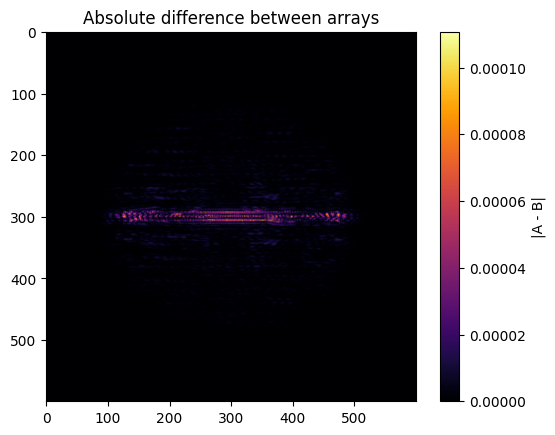

In [20]:
diff = img - I_after_air
plt.imshow(diff, cmap='inferno')
plt.colorbar(label='|A - B|')
plt.title('Absolute difference between arrays')
plt.show()



In [19]:
print(np.shape(img), np.shape(I_after_air))

(600, 600) (600, 600)


Shift (dx=-2, dy=-2) → max |diff| = 1.867e-04
Shift (dx=-2, dy=-1) → max |diff| = 1.699e-04
Shift (dx=-2, dy=0) → max |diff| = 1.467e-04
Shift (dx=-2, dy=1) → max |diff| = 1.794e-04
Shift (dx=-2, dy=2) → max |diff| = 1.985e-04
Shift (dx=-1, dy=-2) → max |diff| = 1.942e-04
Shift (dx=-1, dy=-1) → max |diff| = 1.966e-04
Shift (dx=-1, dy=0) → max |diff| = 1.945e-04
Shift (dx=-1, dy=1) → max |diff| = 1.942e-04
Shift (dx=-1, dy=2) → max |diff| = 1.897e-04
Shift (dx=0, dy=-2) → max |diff| = 1.844e-04
Shift (dx=0, dy=-1) → max |diff| = 1.551e-04
Shift (dx=0, dy=0) → max |diff| = 1.107e-04
Shift (dx=0, dy=1) → max |diff| = 1.713e-04
Shift (dx=0, dy=2) → max |diff| = 1.987e-04
Shift (dx=1, dy=-2) → max |diff| = 1.968e-04
Shift (dx=1, dy=-1) → max |diff| = 1.950e-04
Shift (dx=1, dy=0) → max |diff| = 1.971e-04
Shift (dx=1, dy=1) → max |diff| = 1.960e-04
Shift (dx=1, dy=2) → max |diff| = 1.902e-04
Shift (dx=2, dy=-2) → max |diff| = 1.837e-04
Shift (dx=2, dy=-1) → max |diff| = 1.628e-04
Shift (dx=2,

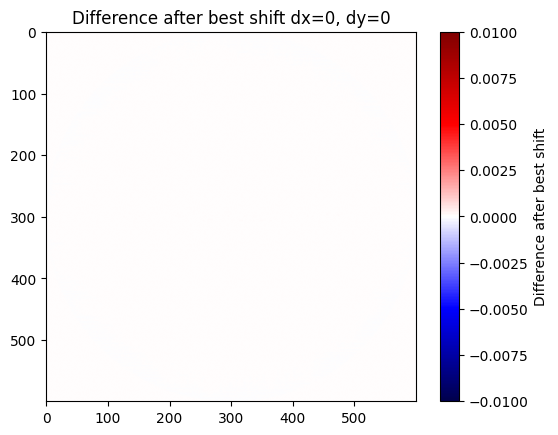

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def shifted_diff(img1, img2, dx, dy):
    """Shift img2 by (dx, dy) and return max absolute difference with img1."""
    shifted = np.roll(img2, shift=(dy, dx), axis=(0, 1))
    return np.max(np.abs(img1 - shifted)), shifted

# Check all small shifts
best_diff = np.inf
best_shift = (0, 0)
best_shifted = None

for dx in [-2, -1, 0, 1, 2]:
    for dy in [-2, -1, 0, 1, 2]:
        diff_val, shifted = shifted_diff(img, I_after_air, dx, dy)
        print(f"Shift (dx={dx}, dy={dy}) → max |diff| = {diff_val:.3e}")
        if diff_val < best_diff:
            best_diff = diff_val
            best_shift = (dx, dy)
            best_shifted = shifted

# Show best result
print(f"\n✅ Best alignment found at shift dx={best_shift[0]}, dy={best_shift[1]} with max diff {best_diff:.3e}")
plt.imshow(img - best_shifted, cmap='seismic', vmin=-1e-2, vmax=1e-2)
plt.colorbar(label='Difference after best shift')
plt.title(f'Difference after best shift dx={best_shift[0]}, dy={best_shift[1]}')
plt.show()


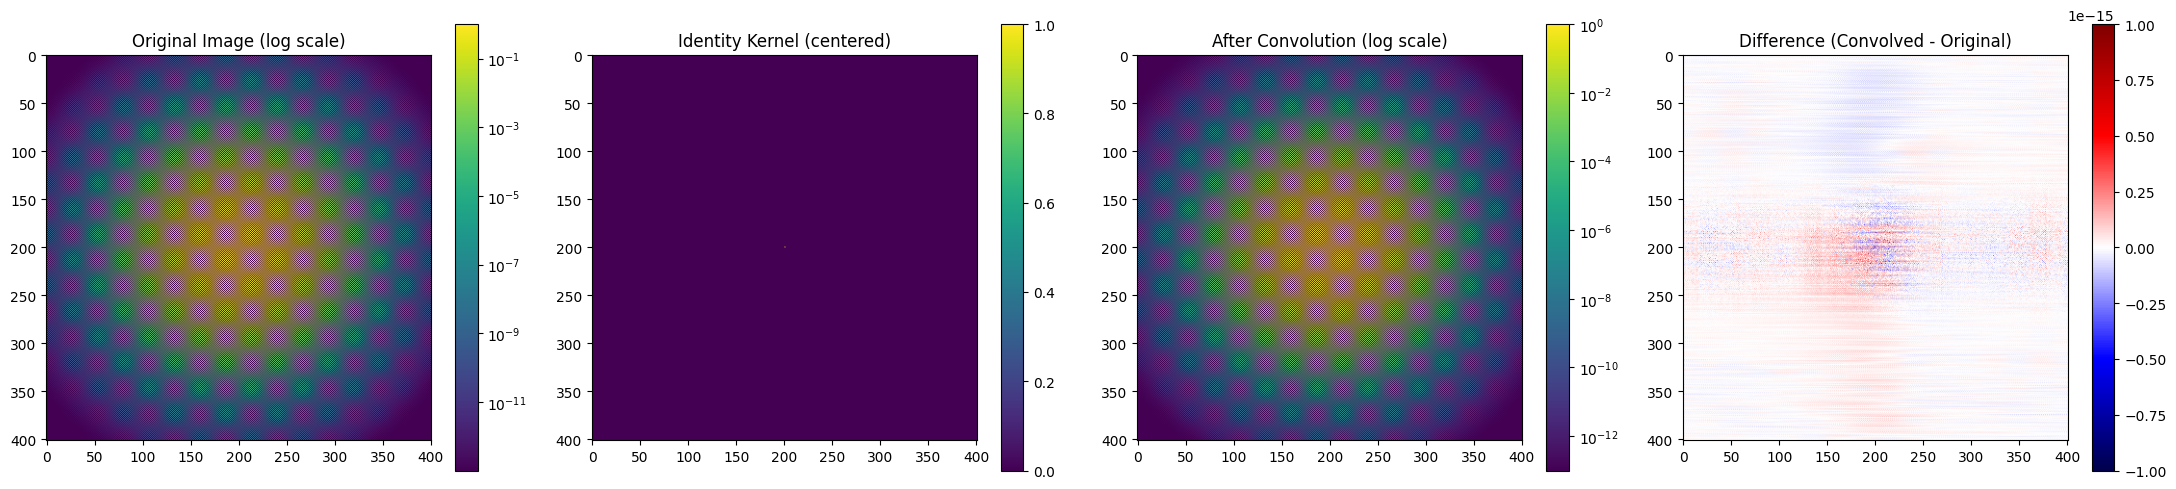

Max absolute difference: 4.440892098500626e-16


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# Step 1: Create an image with pixel-scale variations (checkerboard + decay)
N = 401
x = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, x)

# Checkerboard: alternates 0 and 1 every pixel
checkerboard = ((np.indices((N, N)).sum(axis=0)) % 2)

# Modulate with exponential decay to create wide dynamic range
decay = np.exp(-((X**2 + Y**2) * 20))  # Smooth envelope

# Combine: range will be ~1 to ~1e-13
img = checkerboard * decay + 1e-13
img /= np.max(img)  # Normalize max to 1

# Step 2: Create a centered identity kernel
kernel = np.zeros((N, N))
kernel[N//2, N//2] = 1.0  # Centered, no shift

# Step 3: Convolve
img_convolved = fftconvolve(img, kernel, mode='same')

# Step 4: Compute difference
difference = img_convolved - img

# Step 5: Plot
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

im0 = axes[0].imshow(img, cmap='viridis', norm='log')
axes[0].set_title("Original Image (log scale)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(kernel, cmap='viridis')
axes[1].set_title("Identity Kernel (centered)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(img_convolved, cmap='viridis', norm='log')
axes[2].set_title("After Convolution (log scale)")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(difference, cmap='seismic', vmin=-1e-15, vmax=1e-15)
axes[3].set_title("Difference (Convolved - Original)")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

# Print numerical check
print("Max absolute difference:", np.max(np.abs(difference)))


In [7]:
11//2

5

In [ ]:
%matplotlib widget

plt.figure()
plt.plot(r_centers,radial_hist)
plt.title("Radial histo (nb particles at a given r)")
plt.xlabel("r [µm]")
plt.ylabel("Nb particles")
plt.grid(True)
plt.yscale('log')

plt.figure()
plt.plot(r_centers, radial_density, label='Raw density', color='blue', linewidth=1.5)
plt.plot(r_centers, radial_density_smooth, label='Smoothed density', color='red', linewidth=2)
plt.yscale('log')
plt.title("Radial density")
plt.xlabel("r [µm]")
plt.ylabel("Particles per unit area [1/µm²]")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


In [ ]:
print(len(radial_density_smooth),len(radial_hist), len(radial_density))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def radial_profile_to_2D_centered(radial_values, r_step, N, plot=False):
    """
    Convert a radial profile into a 2D circularly symmetric map,
    with r=0 exactly at the center pixel (only works properly for odd N).

    Parameters:
    - radial_values: 1D array of values as function of radius
    - r_step: spacing between radial values [µm]
    - N: grid size (must be odd for exact centering)
    - plot: show the result

    Returns:
    - kernel_2D: 2D circular symmetric array (N x N)
    """

    if N % 2 == 0:
        raise ValueError("N must be odd to ensure r=0 is centered on a pixel.")

    # Define radial positions for the 1D profile
    r_array = np.arange(len(radial_values)) * r_step

    # Make coordinate grid centered at pixel (N//2, N//2) → r=0
    idx = np.arange(N) - N // 2
    x = idx * r_step
    X, Y = np.meshgrid(x, x)
    R = np.sqrt(X**2 + Y**2)

    # Interpolate 1D radial profile onto 2D grid
    kernel_2D = np.interp(R, r_array, radial_values, left=0, right=0)

    if plot:
        plt.figure(figsize=(5, 5))
        plt.imshow(kernel_2D, origin='lower', cmap='inferno')
        plt.colorbar(label='Value')
        plt.title("Centered Circular 2D Map")
        plt.xlabel("x [µm]")
        plt.ylabel("y [µm]")
        plt.tight_layout()
        plt.show()

    return kernel_2D


In [ ]:
r_step = 1.0
r = np.arange(0, 150, r_step)
radial_vals = np.exp(- (r / 10)**2 )

# Must use odd N!
kernel = radial_profile_to_2D_centered(radial_vals, r_step=r_step, N=301, plot=True)


In [11]:
200 / (1.2*2)

83.33333333333334

Text(0, 0.5, 'deformation [μm]')

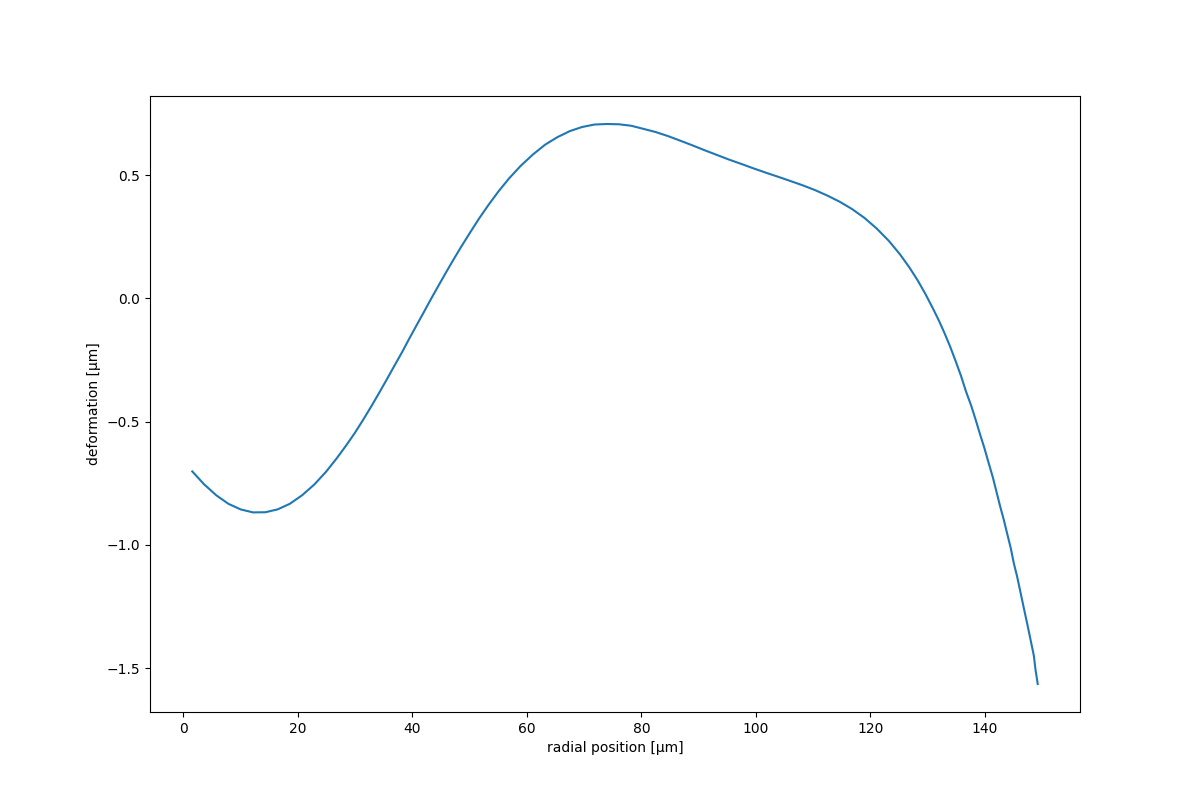

In [18]:
from astropy.io import ascii
import darkfield.mmmUtils_v2 as mu

fia = ascii.read("/home/yu79deg/darkfield_p5438/Seiboth_Fig4")
fiax=fia['col1']
fiay=fia['col2']

mu.figure()
plt.plot(fiax,fiay)
plt.xlabel('radial position [μm]')
plt.ylabel('deformation [μm]')

In [41]:
4.6e5 * (13**2) * (2e11) * (1e-7) / (2e9) / (300**2)

0.008637777777777777

In [40]:
(4.6e5 / (2e9)) * 150

0.0345

In [35]:
13**2

169

In [36]:
(2e11) * (1e-7)

20000.0

In [37]:
20000 * 0.0338

675.9999999999999

In [1]:
0.5e-3 * 10e-2

5e-05

In [2]:
(50/30)**2

2.777777777777778

Max absolute difference: 7.888609052210118e-30


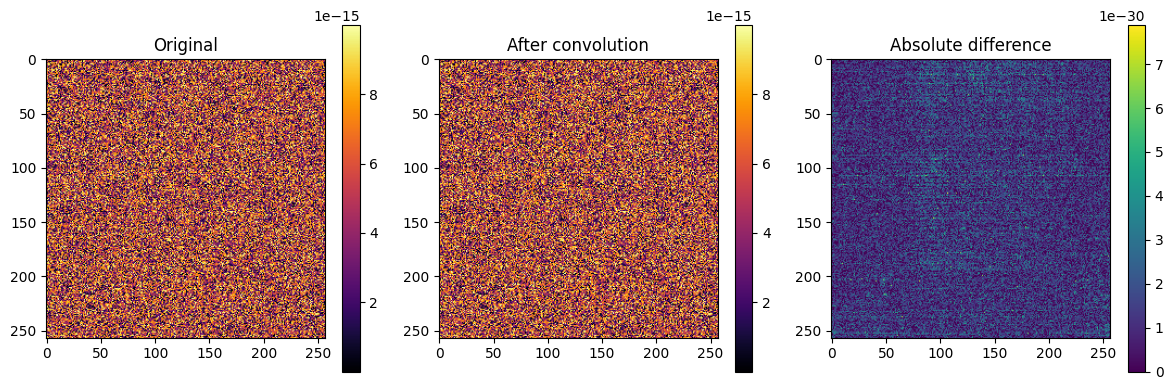

In [6]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

# Create example image
N = 257
LightPipe_img = np.random.rand(N, N)*1e-14  # or use your actual intensity map

# Create identity kernel
kernel2D = np.zeros((N, N))
kernel2D[N//2, N//2] = 1.0

# Convolution
convolved = fftconvolve(LightPipe_img, kernel2D, mode='same')

# Check if they match
print("Max absolute difference:", np.max(np.abs(LightPipe_img - convolved)))

# Plot to visually confirm
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(LightPipe_img, cmap='inferno')
plt.title("Original")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(convolved, cmap='inferno')
plt.title("After convolution")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(np.abs(convolved - LightPipe_img), cmap='viridis')
plt.title("Absolute difference")
plt.colorbar()

plt.tight_layout()
plt.show()


In [4]:
0.25*190

47.5